# KHÁM PHÁ DỮ LIỆU (EDA): AQI VÀ BỆNH LÝ ĐƯỜNG HÔ HẤP THEO COUNTY, 2019–2022

**Môn:** Tương tác dữ liệu trực quan (IDV) - Đồ án cuối kỳ, Chủ đề 12: Phân tích tác động của chất lượng không khí (AQI) đến các bệnh lý đường hô hấp tại các thành phố lớn

**Thực hiện:** Trần Thị Quế Trân (EDA + Dashboard)

**Mục đích:** Vẽ 3–5 biểu đồ tĩnh (Matplotlib/Seaborn) để khảo sát phân phối dữ liệu AQI và tỉ lệ bệnh hô hấp trước khi đưa lên dashboard.

**Dữ liệu đầu vào:** `AQI_Respiratory_Disease_Final.csv` - file bàn giao đã qua tiền xử lý (notebook `Preprocessing_final_v3.ipynb`). Dữ liệu gốc gồm 2 nguồn: AQI từ EPA AirData (`annual_aqi_by_county 2019–2022`, cấp County-Năm) và bệnh/hút thuốc/dân số từ CDC PLACES (age-adjusted prevalence, ước lượng mô hình vùng nhỏ dựa trên BRFSS, không phải khảo sát trực tiếp từng county). Chỉ giữ county có độ phủ dữ liệu AQI ≥ 50% và có city đại diện (chọn theo số trạm quan trắc AQS nhiều nhất).

**Lưu ý xử lý:** Bảng ở dạng long theo `Disease` (mỗi county-năm có 2 dòng: COPD, Current Asthma). Các biến chỉ thuộc county-năm (như `Median_AQI`) được dedupe theo `CountyFIPS`+`Year` trước khi vẽ để tránh đếm đôi.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv('D:/IDV/PROJECT CK/data/AQI_Respiratory_Disease_Final.csv')
df.shape

(6406, 37)

In [15]:
# Bảng ở mức county-year (dedupe 2 dòng bệnh) - dùng cho các biểu đồ chỉ liên quan AQI
county_year = df.drop_duplicates(subset=['CountyFIPS', 'Year']).copy()
print("Số dòng county-year (dedupe):", len(county_year))
print("Số dòng bị trùng do 2 loại bệnh:", df.duplicated(subset=['CountyFIPS','Year']).sum())

Số dòng county-year (dedupe): 3203
Số dòng bị trùng do 2 loại bệnh: 3203


## Biểu đồ 1 - Histogram: Phân phối Median_AQI
**Cột dùng:** `Median_AQI` (mức county-year, đã dedupe)
**Mục đích:** Xem phân phối AQI trung bình giữa các county - lệch phải hay chuẩn.
Tận dụng cột có sẵn `is_extreme_aqi` để tô màu khác cho các điểm ngoại lệ.

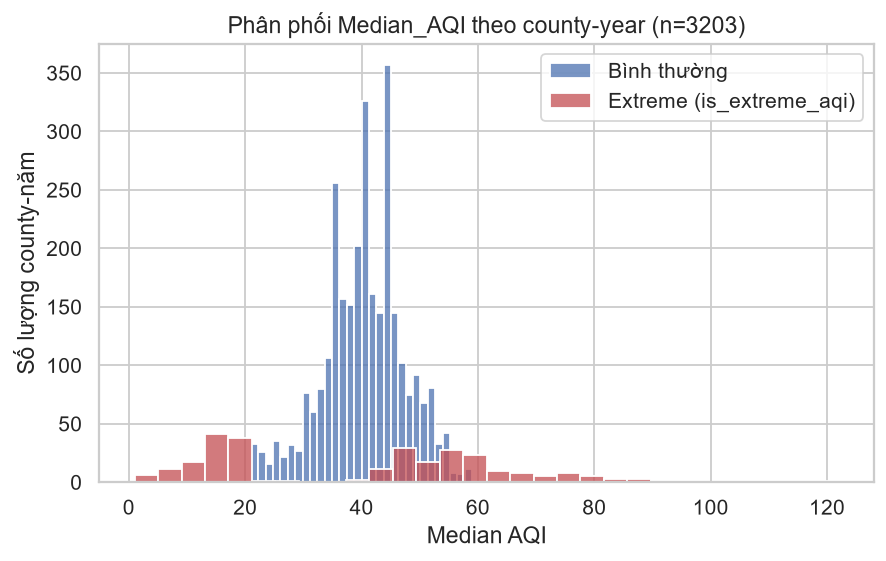

Độ lệch (skewness): 0.22


In [16]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.histplot(data=county_year[~county_year.is_extreme_aqi], x='Median_AQI', bins=30,
             color='#4C72B0', label='Bình thường', ax=ax)
sns.histplot(data=county_year[county_year.is_extreme_aqi], x='Median_AQI', bins=30,
             color='#C44E52', label='Extreme (is_extreme_aqi)', ax=ax)
ax.set_title('Phân phối Median_AQI theo county-year (n=%d)' % len(county_year))
ax.set_xlabel('Median AQI'); ax.set_ylabel('Số lượng county-năm')
ax.legend()
plt.tight_layout(); plt.show()

print("Độ lệch (skewness):", round(county_year['Median_AQI'].skew(), 3))

**Nhận xét:** Phân phối `Median_AQI` hơi lệch phải nhẹ (skew ≈ 0.22), tập trung quanh 35–45 (mức "Moderate" theo chuẩn EPA), với một đuôi các county có AQI thấp (≤20, chất lượng không khí rất tốt) và một số ít county AQI cao (>60). Các điểm được đánh dấu `is_extreme_aqi` nằm chủ yếu ở hai đầu phân phối - đúng như kỳ vọng của một chỉ báo outlier.

## Biểu đồ 2 - Histogram tách theo Disease: Phân phối Disease_AdjPrev
**Cột dùng:** `Disease_AdjPrev`, tách theo `Disease`
**Mục đích:** So sánh phân phối tỉ lệ mắc COPD vs Current Asthma.

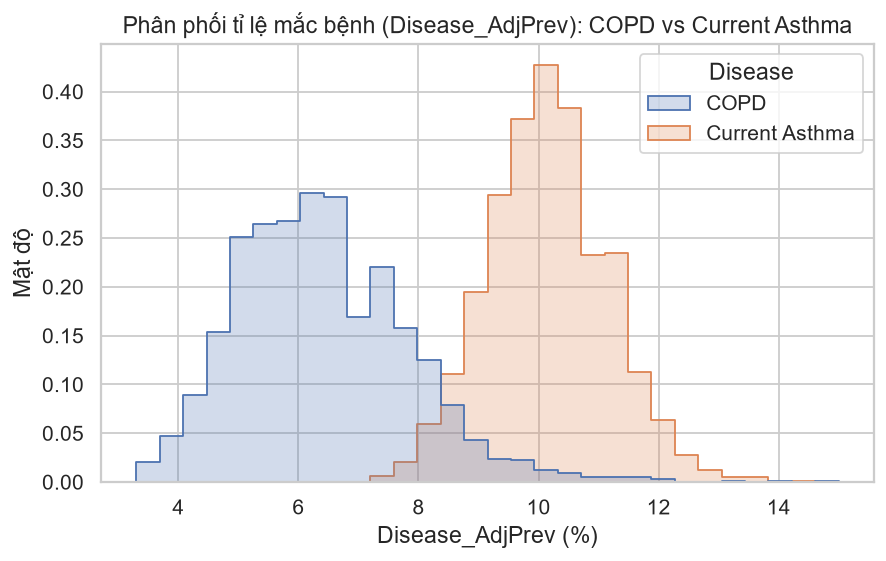

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
COPD,3203.0,6.401686,1.408404,3.3,5.4,6.3,7.3,15.0
Current Asthma,3203.0,10.165876,0.990728,7.2,9.5,10.1,10.8,14.4


In [17]:
fig, ax = plt.subplots(figsize=(7,4.5))
palette_disease = {"COPD": "#4C72B0", "Current Asthma": "#DD8452"}
sns.histplot(data=df, x='Disease_AdjPrev', hue='Disease', bins=30, palette=palette_disease,
             element='step', stat='density', common_norm=False, ax=ax)
ax.set_title('Phân phối tỉ lệ mắc bệnh (Disease_AdjPrev): COPD vs Current Asthma')
ax.set_xlabel('Disease_AdjPrev (%)'); ax.set_ylabel('Mật độ')
plt.tight_layout(); plt.show()

df.groupby('Disease')['Disease_AdjPrev'].describe()

**Nhận xét:** Current Asthma có tỉ lệ mắc trung bình cao hơn (~10.2%) và phân phối hẹp hơn (std ≈ 0.99) so với COPD (~6.4%, std ≈ 1.41). COPD có đuôi phải dài hơn - một số county có tỉ lệ COPD rất cao (>12%), đáng chú ý cho phần storytelling insight sau này.

## Biểu đồ 3 - Boxplot theo Year: Median_AQI
**Cột dùng:** `Median_AQI` (mức county-year), nhóm theo `Year`
**Mục đích:** Xem AQI có đổi nhiều qua 4 năm không.

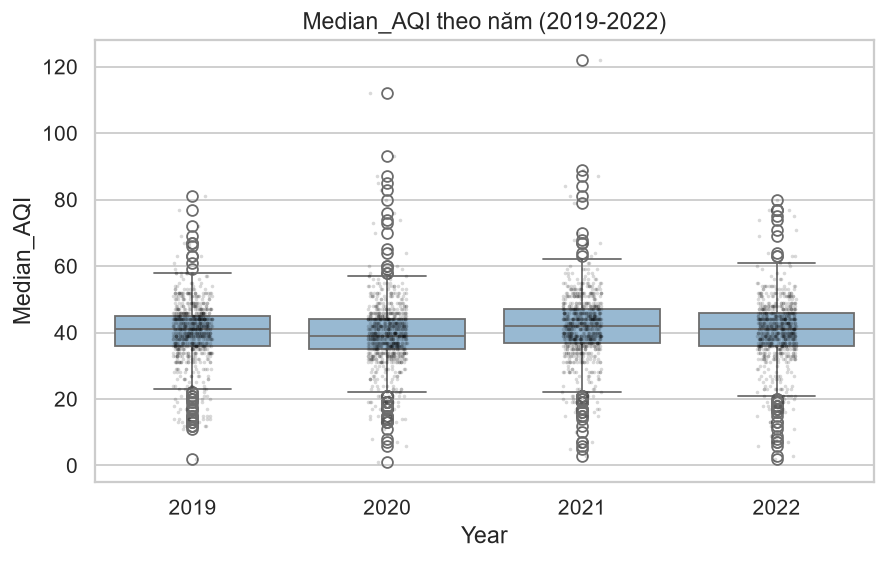

Year
2019    41.0
2020    39.0
2021    42.0
2022    41.0
Name: Median_AQI, dtype: float64

In [18]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.boxplot(data=county_year, x='Year', y='Median_AQI', color='#8FBADB', ax=ax)
sns.stripplot(data=county_year, x='Year', y='Median_AQI', color='black', alpha=0.15, size=2, ax=ax)
ax.set_title('Median_AQI theo năm (2019-2022)')
plt.tight_layout(); plt.show()

county_year.groupby('Year')['Median_AQI'].median()

**Nhận xét:** Median của Median_AQI gần như không đổi qua 4 năm (39–42), phân phối và các outlier ở mỗi năm cũng tương tự nhau. → Với chỉ 4 mốc năm, đây là xu hướng ngắn hạn, không đủ để kết luận xu hướng dài hạn - sẽ nêu rõ giới hạn này trong báo cáo. 
Việc gần như không đổi qua các năm là hợp lý vì `Disease_AdjPrev`/`Smoking_AdjPrev` từ PLACES biến thiên giữa các county nhiều hơn hẳn so với biến thiên theo năm trong cùng 1 county - nên phân tích chính của đề tài nên đặt trọng tâm vào so sánh giữa các county, không phải xu hướng theo thời gian.

## Biểu đồ 4 - Scatter: Median_AQI vs Disease_AdjPrev
**Cột dùng:** `Median_AQI`, `Disease_AdjPrev`, màu theo `Disease`
**Mục đích:** Bản nháp tĩnh của biểu đồ chính (#7) sẽ đưa lên dashboard (scatter + OLS). Highlight `is_extreme_disease`.

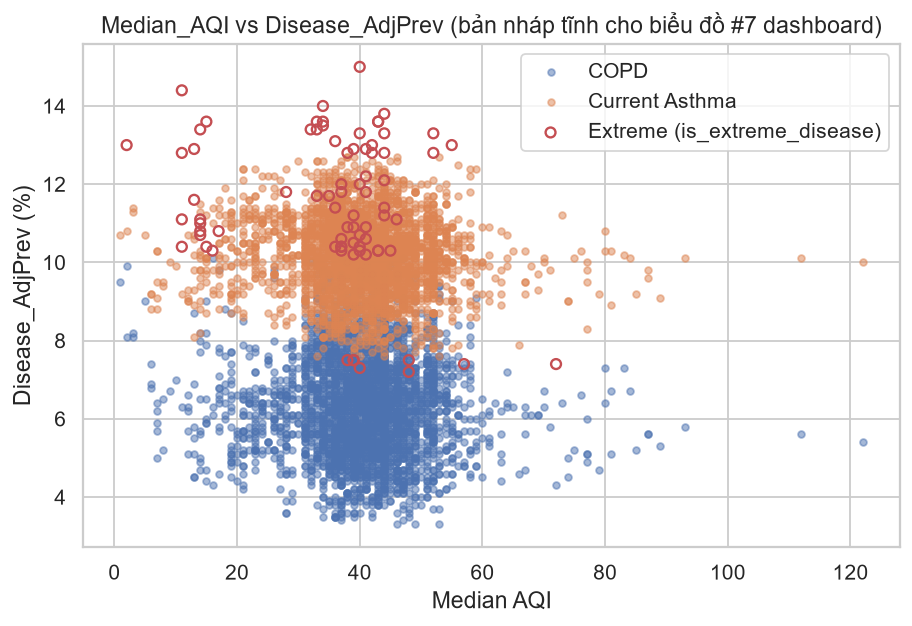

COPD - Pearson corr(Median_AQI, Disease_AdjPrev): -0.075
Current Asthma - Pearson corr(Median_AQI, Disease_AdjPrev): -0.093


In [19]:
fig, ax = plt.subplots(figsize=(7.2,5))
for disease, color in palette_disease.items():
    sub = df[(df.Disease==disease) & (~df.is_extreme_disease)]
    ax.scatter(sub['Median_AQI'], sub['Disease_AdjPrev'], s=14, alpha=0.5, color=color, label=disease)
sub_ext = df[df.is_extreme_disease]
ax.scatter(sub_ext['Median_AQI'], sub_ext['Disease_AdjPrev'], s=30, facecolors='none',
           edgecolors='#C44E52', linewidths=1.3, label='Extreme (is_extreme_disease)')
ax.set_xlabel('Median AQI'); ax.set_ylabel('Disease_AdjPrev (%)')
ax.set_title('Median_AQI vs Disease_AdjPrev (bản nháp tĩnh cho biểu đồ #7 dashboard)')
ax.legend()
plt.tight_layout(); plt.show()

for d in df.Disease.unique():
    sub = df[df.Disease==d]
    print(d, "- Pearson corr(Median_AQI, Disease_AdjPrev):", round(sub['Median_AQI'].corr(sub['Disease_AdjPrev']), 3))

**Nhận xét (quan trọng cho Insight & mô hình dự báo):** Tương quan tuyến tính giữa `Median_AQI` và `Disease_AdjPrev` **rất yếu và hơi âm** đối với cả 2 bệnh (r ≈ -0.08). Nhìn scatter cũng thấy 2 "dải" ngang tách biệt rõ theo loại bệnh (Asthma cao hơn COPD) nhưng gần như phẳng theo trục AQI - nghĩa là **chỉ riêng AQI không giải thích tốt sự khác biệt tỉ lệ mắc bệnh giữa các county**. Cho thấy ở bước phân tích: mô hình hồi quy tuyến tính chỉ dùng Median_AQI có thể có R² thấp; nên cân nhắc đưa thêm biến khác (xem heatmap bên dưới) hoặc nêu rõ giới hạn này trong phần Storytelling/Limitations thay vì cố kết luận AQI là nguyên nhân chính.

## Biểu đồ 5 - Heatmap tương quan
**Cột dùng:** `Median_AQI`, `Smoking_AdjPrev`, `Disease_AdjPrev`, `Log_Population`

**Mục đích:** Biến nào liên quan biến nào trước khi đưa vào mô hình.

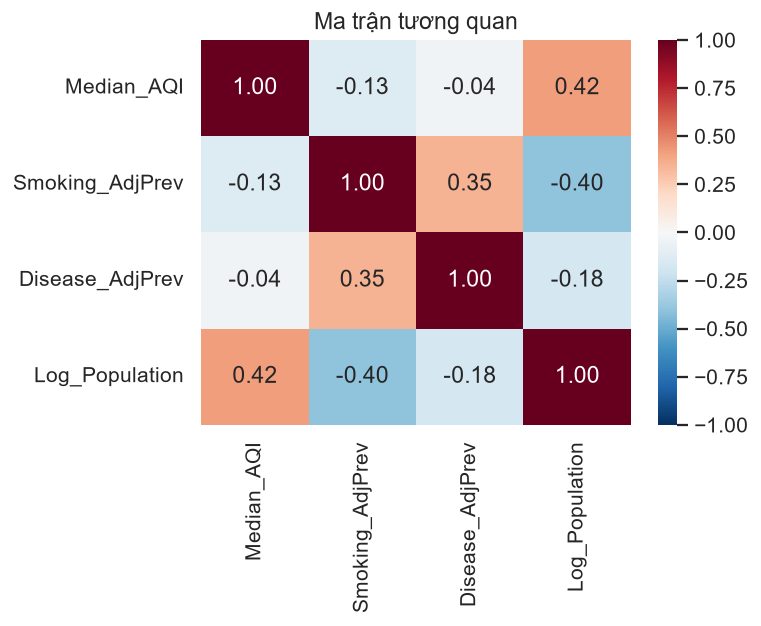

,Median_AQI,Smoking_AdjPrev,Disease_AdjPrev,Log_Population
Median_AQI,1.000000,-0.134778,-0.044052,0.420651
Smoking_AdjPrev,-0.134778,1.000000,0.346857,-0.398888
Disease_AdjPrev,-0.044052,0.346857,1.000000,-0.175279
Log_Population,0.420651,-0.398888,-0.175279,1.000000


In [20]:
cols = ['Median_AQI', 'Smoking_AdjPrev', 'Disease_AdjPrev', 'Log_Population']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Ma trận tương quan')
plt.tight_layout(); plt.show()
corr

**Nhận xét:** `Smoking_AdjPrev` tương quan với `Disease_AdjPrev` (r ≈ 0.35) **mạnh hơn nhiều** so với `Median_AQI` (r ≈ -0.04). `Log_Population` cũng tương quan vừa phải với AQI (0.42, county đông dân thường AQI cao hơn) và âm với Smoking (-0.40, có thể do đô thị hóa). → Gợi ý quan trọng cho bước phân tích : nếu mô hình dự báo chỉ hồi quy `Disease_AdjPrev` theo `Median_AQI` đơn biến thì sẽ yếu; nên thử thêm Smoking_AdjPrev làm biến kiểm soát/độc lập bổ sung (hoặc ít nhất nêu rõ trong báo cáo rằng khói thuốc là yếu tố liên quan mạnh hơn AQI).
Cần lưu ý `Disease_AdjPrev` là ước lượng mô hình vùng nhỏ (model-based), có xu hướng được làm mượt (smoothing) giữa các vùng lân cận - nên tương quan yếu quan sát được một phần phản ánh bản chất ước lượng này, không chỉ là AQI không có tác động thực tế. Đây là giới hạn (Limitations) cần nêu rõ trong báo cáo, không nên kết luận "AQI không ảnh hưởng đến bệnh hô hấp".

## Tổng kết 5 biểu đồ 
1. Histogram Median_AQI - phân phối lệch phải nhẹ, tập trung mức Moderate.
2. Histogram Disease_AdjPrev theo Disease - Asthma cao & hẹp hơn, COPD thấp & đuôi dài hơn.
3. Boxplot Median_AQI theo Year - không đổi nhiều qua 4 năm (đúng dự đoán).
4. Scatter Median_AQI vs Disease_AdjPrev - tương quan rất yếu, cần lưu ý khi làm mô hình.
5. Heatmap tương quan - Smoking liên quan bệnh mạnh hơn AQI; Population liên quan cả AQI và Smoking.
